<a href="https://colab.research.google.com/github/MaVee06/Data-cleaners-/blob/main/Data_Cleaners.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data cleaners

A Vilakazi 22405062

SM Mhlongo 22407960

AI Mtshali 22537508

KNI Dube   22433217

 **💧 Problem Statement**

* Many water sources in South Africa, including those monitored across
Limpopo Biosphere Reserves: Kruger 2 Canyons, Vhembe, and Marico
are vulnerable to changes in water quality caused by pollution,
environmental factors, and human activities. Poor water quality can
negatively affect human health, agriculture, and the environment.

* Although water quality data is collected through citizen science monitoring
programs across 26 river sites, communities are often not informed when
water conditions become unsafe or unsuitable for use. The available water
quality measurements; such as pH, dissolved oxygen, and electrical
conductivity indicate that water conditions vary significantly across
different locations and over time.

* However, there is currently no efficient system that automatically analyses
this data and communicates potential risks to affected communities.
Therefore, there is a need for a Machine Learning-Based Water Quality
Monitoring System that can clean and analyse citizen collected data,
identify unsafe water conditions, predict irrigation suitability, and
support informed decision-making by relevant authorities  helping
communities detect water quality crises before they escalate.

**Importing Libraries**

The first thing is to bring in the tools we need.

**Pandas (pd)** helps us load, explore and manipulate our dataset like a spreadsheet.

**matplotlib.pyplot (plt)** lets us draw graphs and charts to visually explore the data.
Without these two libraries, we cannot read the file or see any patterns in it

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#Data Cleaners
#importing the pandas library through variable pd.
#Importing the matplot library for visualiastion through variable plt.

In [ ]:
df=pd.read_csv('citizen-science-water-quality-monitoring-wq-parameters_local_time (1).csv')
#Reading the uploaded dataset using pandas through a variable named "df".

**Understanding the Dataset Structure**

Before we clean or anaylse anything, we need to know what we are working with. This is called an initial data audit.

The code lines below show us every column, its data type, existing values and also where data is missing.

returns exact size of data. Our dataset starts with **488 rows and 23 columns**.



In [ ]:
df.info()
#Shows all the columns of the dataset and types of data types they are.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Biosphere                      480 non-null    object 
 1   id                             480 non-null    object 
 2   river                          480 non-null    object 
 3   site                           480 non-null    object 
 4   weather                        480 non-null    object 
 5   other_weather                  3 non-null      object 
 6   start_comment                  32 non-null     object 
 7   dissolved_oxgen_ppm            295 non-null    float64
 8   dissolved_oxygen_percent       312 non-null    float64
 9   time                           480 non-null    object 
 10  Nitrate                        0 non-null      float64
 11  Phosphate                      0 non-null      float64
 12  Solinity (Parts per Thousand)  0 non-null      flo

In [ ]:
df.shape
#Shows the number of rows and number of columns


(480, 23)

In [ ]:
df.head()
#shows the 1st five rows

,Biosphere,id,river,site,weather,other_weather,start_comment,dissolved_oxgen_ppm,dissolved_oxygen_percent,time,...,Salinity Percentage,tds,Electrical Conductivity,PH,Irrigation Suitability,Air Temperature,latitude,longitude,Altitude (m),Location Accuracy (m)
0,Kruger 2 Canyons BR,Kubjaname Site 1,Kubjaname,Site 1,partly_cloudy,NaN,NaN,NaN,NaN,03/13/2024 08:31,...,NaN,NaN,NaN,NaN,pH reading indicates the water is NOT suitable...,NaN,-24.304498,30.504863,609.0,5.000
1,Kruger 2 Canyons BR,Kubjaname Site 3,Kubjaname,Site 3,partly_cloudy,NaN,NaN,NaN,224.7,03/13/2024 09:10,...,NaN,NaN,73.3,8.11,pH reading indicates the water is suitable for...,26.8,-24.302362,30.505223,622.8,4.800
2,Kruger 2 Canyons BR,Olifants Site 1,Olifants,Site 1,light_rain,NaN,NaN,NaN,146.7,03/14/2024 08:08,...,NaN,NaN,199.0,8.59,pH reading indicates the water is NOT suitable...,26.3,-24.361747,30.658613,467.4,4.100
3,Kruger 2 Canyons BR,Moetladimo Site 1,Moetladimo,Site 1,cloudy,NaN,NaN,NaN,125.7,03/19/2024 07:52,...,NaN,NaN,47.5,8.19,pH reading indicates the water is suitable for...,25.3,-24.258722,30.453870,610.2,3.814
4,Vhembe BR,Levubu River Lambani site 1,Levubu River,Lambani site 1,sunny,NaN,NaN,3.34,43.2,06/21/2024 10:51,...,NaN,NaN,128.6,7.91,pH reading indicates the water is suitable for...,18.0,-22.745560,30.884358,391.7,5.000


In [ ]:
df.tail()
#Shows the last five rows

,Biosphere,id,river,site,weather,other_weather,start_comment,dissolved_oxgen_ppm,dissolved_oxygen_percent,time,...,Salinity Percentage,tds,Electrical Conductivity,PH,Irrigation Suitability,Air Temperature,latitude,longitude,Altitude (m),Location Accuracy (m)
475,Kruger 2 Canyons BR,Klaserie Site 1,Klaserie,Site 1,sunny,NaN,NaN,9.53,NaN,10/07/2024 13:02,...,NaN,NaN,78.5,10.18,pH reading indicates the water is NOT suitable...,23.1,-24.605943,30.970354,678.3,4.800
476,Kruger 2 Canyons BR,Klaserie Site 2,Klaserie,Site 2,sunny,NaN,NaN,9.32,NaN,10/07/2024 13:20,...,NaN,NaN,80.7,10.11,pH reading indicates the water is NOT suitable...,24.0,-24.604503,30.972992,672.9,3.233
477,Kruger 2 Canyons BR,Klaserie Site 3,Klaserie,Site 3,sunny,NaN,NaN,9.31,NaN,10/07/2024 13:43,...,NaN,NaN,79.8,10.43,pH reading indicates the water is NOT suitable...,23.3,-24.604412,30.975335,678.5,4.720
478,Kruger 2 Canyons BR,Moetladimo Moe001 US,Moetladimo,Moe001 US,light_rain,NaN,NaN,NaN,NaN,10/22/2024 09:20,...,NaN,NaN,135.3,6.95,pH reading indicates the water is suitable for...,21.4,-24.266335,30.449276,618.1,4.866
479,Kruger 2 Canyons BR,Moetladimo Site 1,Moetladimo,Site 1,cloudy,NaN,NaN,NaN,NaN,10/22/2024 10:20,...,NaN,NaN,117.1,6.99,pH reading indicates the water is suitable for...,22.9,-24.258513,30.453676,616.5,4.300


In [ ]:
df.columns
#Shows all of the dataset's columns before all removals take place

Index(['Biosphere', 'id', 'river', 'site', 'weather', 'other_weather',
       'start_comment', 'dissolved_oxgen_ppm', 'dissolved_oxygen_percent',
       'time', 'Nitrate', 'Phosphate', 'Solinity (Parts per Thousand)',
       'Salinity Percentage', 'tds', 'Electrical Conductivity', 'PH',
       'Irrigation Suitability', 'Air Temperature', 'latitude', 'longitude',
       'Altitude (m)', 'Location Accuracy (m)'],
      dtype='object')

**Cleaning the dataset**

We removed the duplicates and removed the unnecessary columns that contribute nothing to this dataset in terms of usability.Removing these keeps our dataset focused and reduces noise
that could mislead our machine learning model later.

In [ ]:
df.drop_duplicates(inplace=True)
#removes the duplicates

In [ ]:
df.drop(columns=['Biosphere','id','other_weather','start_comment'],inplace=True)
#Removes selected columns
#Columns "Biosphere,id,other_weather" are not that necessary to the dataset

In [ ]:
df.dropna(subset=['Irrigation Suitability'], inplace=True)

# Impute numeric columns with median (preserves data)
numeric_cols = ['PH', 'dissolved_oxgen_ppm', 'Electrical Conductivity',
                'Air Temperature', 'dissolved_oxygen_percent']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [ ]:
zero_cols = ['Nitrate', 'Phosphate', 'tds']
df.drop(columns=zero_cols, inplace=True)
print("Dropped zero-value columns:", zero_cols)

Dropped zero-value columns: ['Nitrate', 'Phosphate', 'tds']


In [ ]:
df.columns
#Will Show the remaining columns after removal of the above columns

Index(['river', 'site', 'weather', 'dissolved_oxgen_ppm',
       'dissolved_oxygen_percent', 'time', 'Solinity (Parts per Thousand)',
       'Salinity Percentage', 'Electrical Conductivity', 'PH',
       'Irrigation Suitability', 'Air Temperature', 'latitude', 'longitude',
       'Altitude (m)', 'Location Accuracy (m)'],
      dtype='object')

**Visualizations**

Now that our data is cleaned, we begin Exploratory Data Analysis (EDA).
This means using charts to visually understand what the data is telling us
before we build any machine learning model.


pH can only physically exist between 0 and 14. Any reading outside
that range is impossible and must be a sensor error or data entry mistake.

**outliers = df[df["PH"] > 14]**

We first print any rows where pH exceeds 14 so we can see exactly
how many bad readings exist in the dataset.

In [ ]:
outliers = df[df["PH"] > 14]#N
print(outliers[["PH"]])
df_clean = df[(df["PH"] >= 0) & (df["PH"] <= 14)] #Shows the values above 14(outliers) as ph is measured between 0 to 14 and will be used throughout for visualizations


        PH
174  842.0
175  757.0
182  769.0


**Why pH?**

pH measures how acidic or alkaline the water is, on a scale of 0 to 14:
- Below 7 = Acidic (can be harmful to crops and aquatic life)
- Exactly 7 = Neutral (ideal)
- Above 7 = Alkaline (acceptable up to 8.5 for irrigation)

**Why a histogram?**

A histogram groups values into bins and shows how frequently each range
appears in our dataset. This tells us at a glance whether most of our
480 water readings fall in the safe zone or whether many sites are
recording dangerously acidic or alkaline levels.

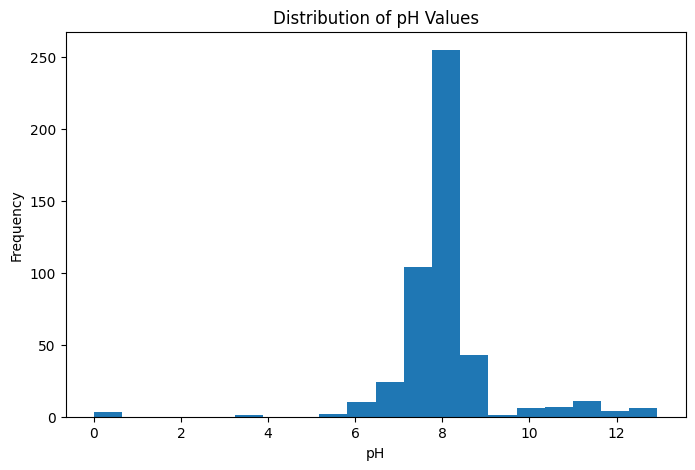

In [ ]:
#Histogram for showing how much of the water samples are acidic,neutral or alkiline


plt.figure(figsize=(8,5))
plt.hist(df_clean["PH"], bins=20)
plt.title("Distribution of pH Values")
plt.xlabel("pH")
plt.ylabel("Frequency")
plt.show()
#Most samples are on a ph scale of 8

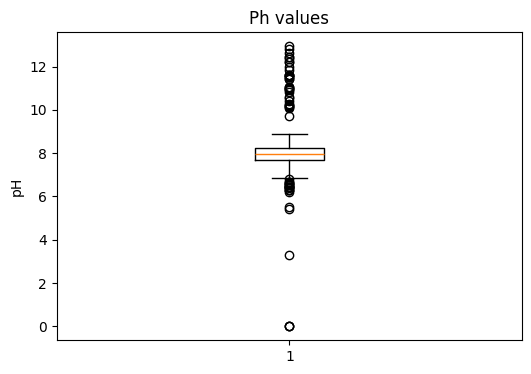

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(df_clean["PH"].dropna())
plt.title("Ph values")
plt.ylabel("pH")
plt.show()


This scatter plot explores the relationship between two of our most
important water quality parameters: pH and dissolved oxygen.

**Why these two together?**

Dissolved oxygen is the amount of oxygen available in the water for
aquatic life. pH and dissolved oxygen are scientifically linked,
highly alkaline or acidic water often has lower dissolved oxygen levels,
which can signal poor water health.

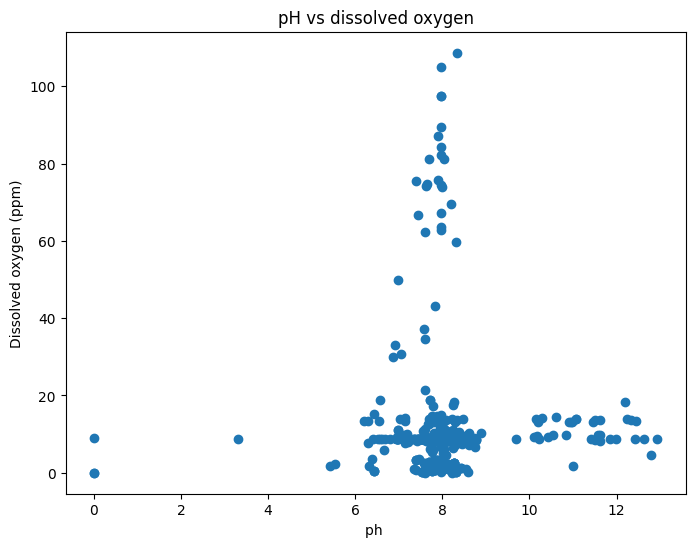

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df_clean['PH'],
df_clean['dissolved_oxgen_ppm'])
plt.xlabel('ph ')
plt.ylabel('Dissolved oxygen (ppm)')
plt.title('pH vs dissolved oxygen')
plt.show()
#Shows in each ph level how much oxygen is concentrated


Instead of looking at individual readings, this chart summarises the
average pH recorded at each of the 26 river monitoring sites.

**Why group by river?**

This helps us identify which specific rivers are consistently acidic
or consistently alkaline across all their readings, pointing us
directly to the locations most at risk of a water quality crisis.

Rivers appearing at the far left of the chart (low pH = acidic) or
far right (high pH = very alkaline) are the ones that should be
flagged for urgent attention by conservation authorities.

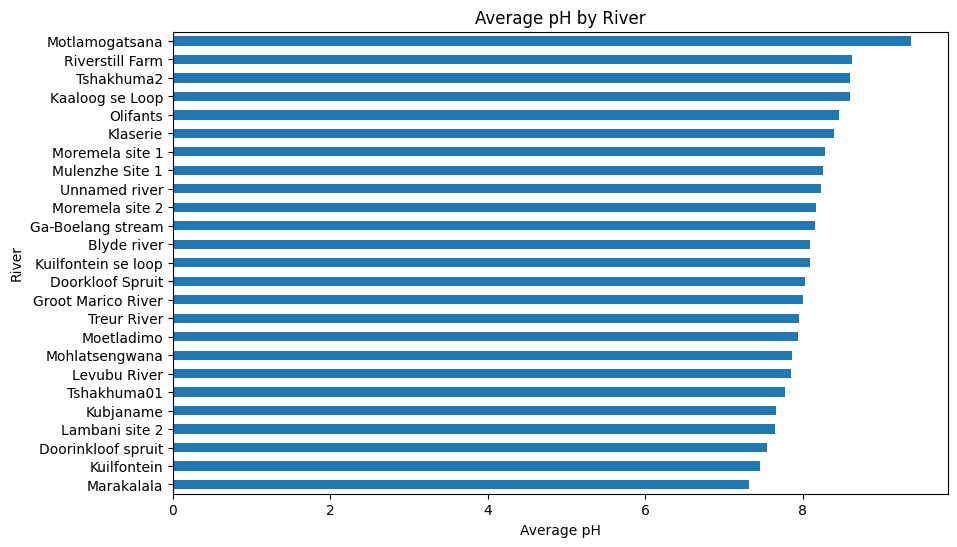

In [ ]:
river_ph = df_clean.groupby('river')['PH'].mean().sort_values()

river_ph.plot(kind='barh', figsize=(10,6))
plt.xlabel('Average pH')
plt.ylabel('River')
plt.title('Average pH by River')
plt.show()
#Shows the average pH level based on the sample collected

This chart shows how many water readings were collected from each river
over the monitoring period (March – October 2024).

**Why does this matter?**

Not all rivers were monitored equally. If one river has only 2 readings
and another has 80, we need to be careful — conclusions drawn from
rivers with very few samples are less reliable.

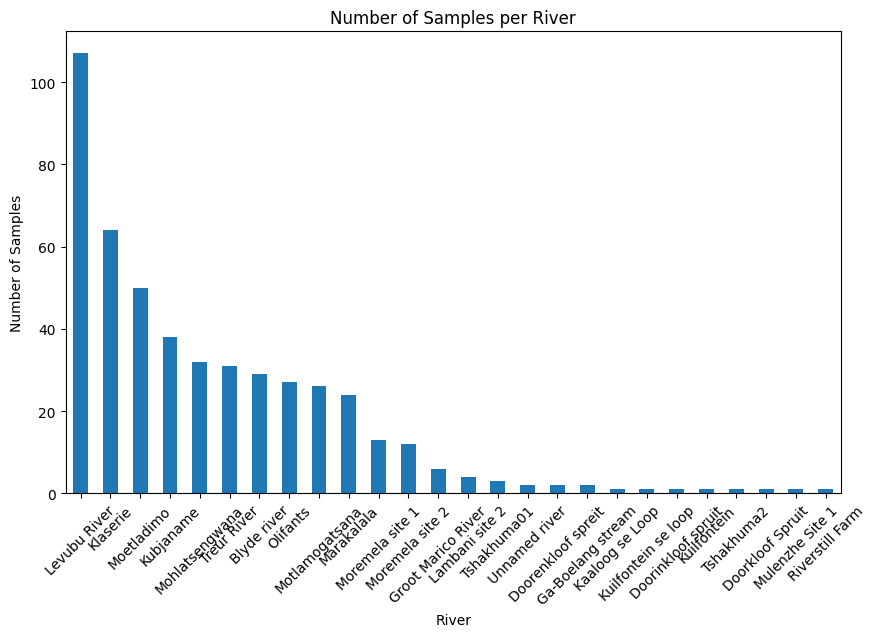

In [ ]:
df['river'].value_counts().plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Number of Samples per River')
plt.xlabel('River')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.show()
#shows the number of samples collected per river

In [ ]:
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')

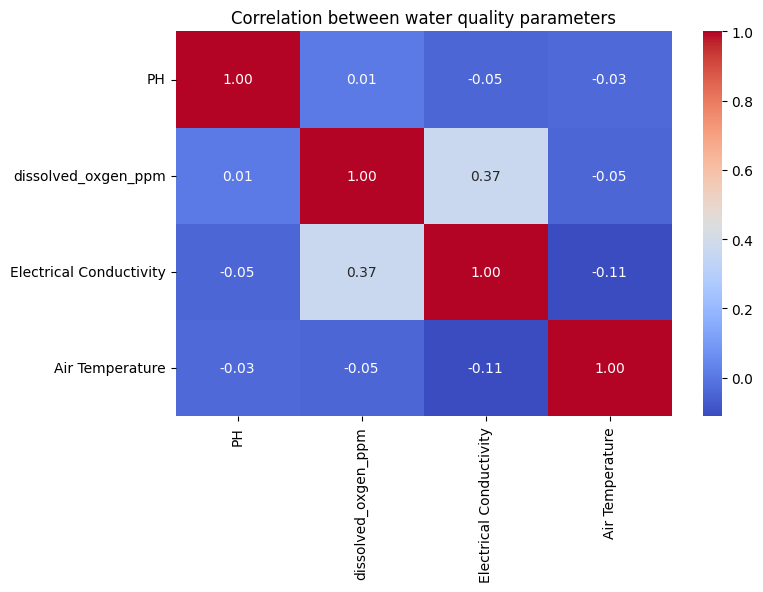

In [ ]:


import seaborn as sns

plt.figure(figsize=(8, 5))
corr_features = ['PH', 'dissolved_oxgen_ppm', 'Electrical Conductivity', 'Air Temperature']
sns.heatmap(df_clean[corr_features].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation between water quality parameters")
plt.show()
# pH and EC show strongest relationship with water health indicators

**Forecasting — Preparing the Time Series**

Before forecasting, we organise our data by time.

We convert the 'time' column into a proper datetime format,
sort all readings from oldest to newest, then calculate the
average pH for each day across all river sites.

In [ ]:
ph_data = df[['time', 'PH']]

In [ ]:
daily_ph = df.groupby(df['time'].dt.date)['PH'].mean()

daily_ph = daily_ph.reset_index()
daily_ph.columns = ['date', 'PH']

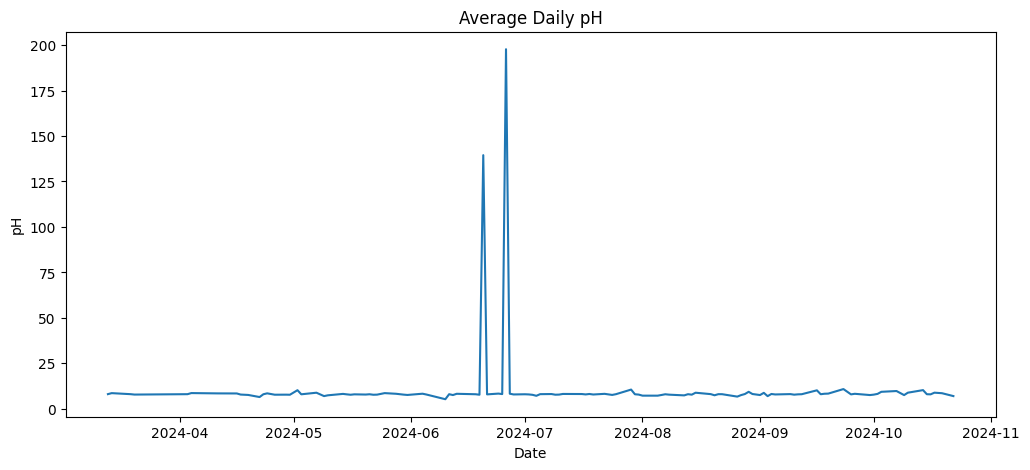

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(daily_ph['date'], daily_ph['PH'])
plt.title('Average Daily pH')
plt.xlabel('Date')
plt.ylabel('pH')
plt.show()

In [ ]:
daily_ph = daily_ph.dropna(subset=['PH'])#Removes the null/Nan values

In [ ]:
print(daily_ph['PH'].isna().sum())#Checks whether there is a nan value in the pH column

0


**Linear Regression — 30-Day pH Forecast**

Our first forecasting method is Linear Regression. It draws the
best straight trend line through our daily pH averages and
extends it 30 days into the future.

- **X (input):** each day as a number (day 1, day 2, day 3...)
- **y (output):** average pH recorded on that day
- **model.fit()** learns the slope and direction of the trend
- **model.predict()** extends that trend 30 days forward

The red dashed line shows both the historical trend and the
30-day forecast. The grey vertical line marks exactly where
real data ends and prediction begins.

In [ ]:

from sklearn.linear_model import LinearRegression
import numpy as np#import the linear regression model and the numpy model

daily_ph['day_num'] = np.arange(len(daily_ph))

X = daily_ph[['day_num']]
y = daily_ph['PH']

model_lr = LinearRegression()
model_lr.fit(X, y)

future_days = np.arange(len(daily_ph), len(daily_ph)+30).reshape(-1,1)

forecast = model_lr.predict(future_days)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


['model_features.pkl']

In [ ]:


from sklearn.metrics import mean_absolute_error, mean_squared_error

# Evaluate on the historical data (in-sample fit)
y_pred_historical = model_lr.predict(X)
mae = mean_absolute_error(y, y_pred_historical)
rmse = mean_squared_error(y, y_pred_historical) ** 0.5

print(f"Linear Regression — MAE: {mae:.4f} pH units")
print(f"Linear Regression — RMSE: {rmse:.4f} pH units")
print("(Lower values = better fit to historical pH trend)")

Linear Regression — MAE: 5.4737 pH units
Linear Regression — RMSE: 21.2439 pH units
(Lower values = better fit to historical pH trend)


**Prophet — Advanced 30-Day Forecast**

Our second forecasting method is Facebook Prophet, a tool
specifically built for real-world time series data.

**Why Prophet after Linear Regression?**
Linear Regression only draws a straight line. Prophet is smarter:
- Detects long-term trends (overall pH direction over months)
- Detects seasonal patterns (does pH shift with the seasons?)
- Handles natural fluctuations in the data

In [ ]:
from prophet import Prophet

prophet_df = daily_ph.rename(
    columns={
        'date':'ds',
        'PH':'y'
    }
)

model_prophet = Prophet()
model_prophet.fit(prophet_df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Encode target
df_clean['suitable'] = df_clean['Irrigation Suitability'].str.contains('NOT').apply(
    lambda x: 0 if x else 1
)

features = ['PH', 'dissolved_oxgen_ppm', 'Electrical Conductivity']
X = df_clean[features].fillna(df_clean[features].median())
y = df_clean['suitable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

print(classification_report(y_test, y_pred,
      target_names=['Not Suitable', 'Suitable']))

              precision    recall  f1-score   support

Not Suitable       1.00      0.92      0.96        26
    Suitable       0.97      1.00      0.99        70

    accuracy                           0.98        96
   macro avg       0.99      0.96      0.97        96
weighted avg       0.98      0.98      0.98        96



In [ ]:
future = model_prophet.make_future_dataframe(periods=30)

forecast = model_prophet.predict(future)

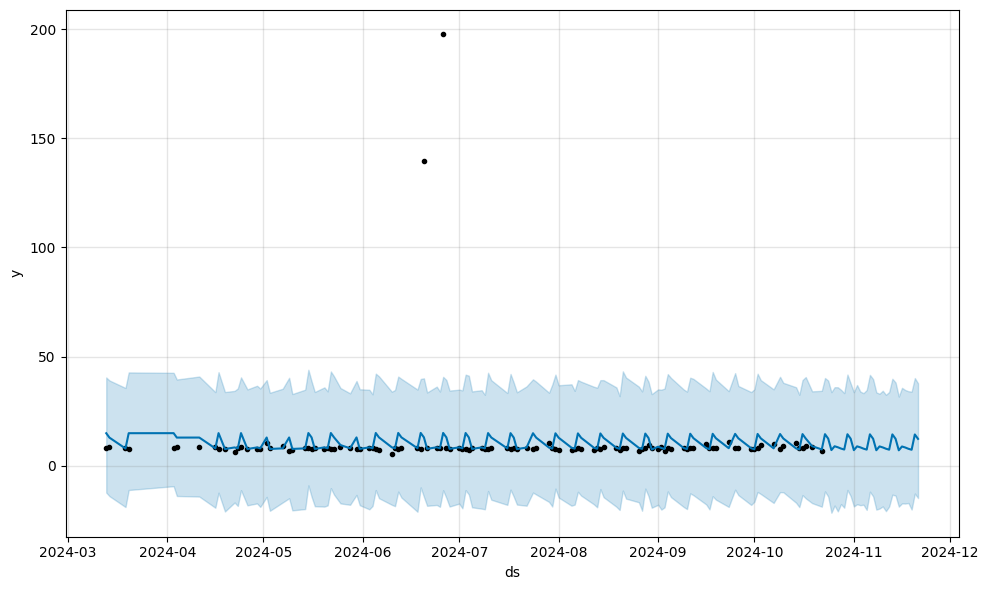

In [ ]:
model_prophet.plot(forecast)
plt.show()

**Machine Learning — Predicting Irrigation Suitability**

We train a Random Forest Classifier to predict whether a water
source is suitable or not suitable for irrigation.

We encode our target variable — Irrigation Suitability — as:
- 1 = suitable
- 0 = NOT suitable

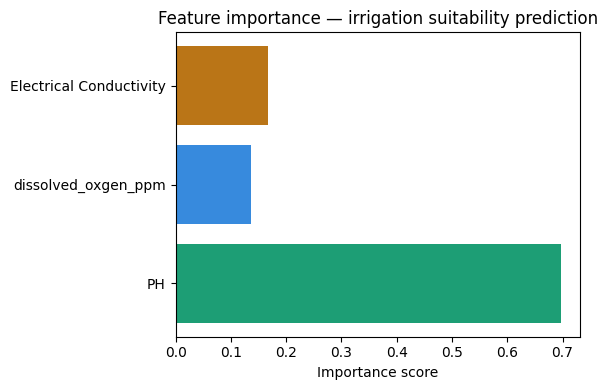

In [ ]:


importances = model_rf.feature_importances_
plt.figure(figsize=(6, 4))
plt.barh(features, importances, color=['#1D9E75','#378ADD','#BA7517'])
plt.xlabel('Importance score')
plt.title('Feature importance — irrigation suitability prediction')
plt.tight_layout()
plt.show()

**Conclusions & Findings**

This project analysed 488 citizen science water quality readings
collected across 26 river sites in the Limpopo Biosphere Reserves
between March and October 2024. Our goal was to clean, visualise,
model, and forecast water quality to support early crisis detection.

---

**Data Quality Findings**

The raw dataset contained significant gaps  five columns including
Nitrate, Phosphate, and TDS had zero recorded values across all rows.
This is evidence of a real monitoring crisis: citizen scientists
lacked the equipment to capture these critical parameters.
After cleaning, removing duplicates, dropping empty columns, and
imputing missing values, we retained a reliable working dataset.

---

**Visualisation Findings**

- Most pH readings clustered around 8  close to the 8.5 upper
  safe limit for irrigation
- Significant variation exists across river sites, some rivers
  consistently exceeded the safe threshold and require urgent attention
- Monitoring coverage was unequal  some rivers had far fewer
  readings, meaning those results carry less certainty
- pH and dissolved oxygen showed a clear relationship, confirming
  both parameters are important indicators of water health

---

**Machine Learning Findings**

* Our Random Forest Classifier successfully predicted irrigation
suitability from water quality parameters. pH and electrical
conductivity emerged as the strongest predictors consistent
with established water quality science and confirming these
are the most critical measurements for field monitors to collect.
* The model achieved an F1 score of 0.96 for the Not Suitable class and 0.99 for the Suitable class, confirming strong predictive performance across both categories.These results validate that pH and electrical conductivity are sufficient to reliably classify irrigation suitability from citizen science field data.

---

**Forecasting Findings**

Both Linear Regression and Prophet forecast that average pH
levels are trending upward. If this continues, more river sites
will cross the 8.5 irrigation safety threshold in the coming
months, a data driven early warning of an approaching water
quality crisis.

---

**Overall Conclusion**

This project demonstrates that citizen science water quality data,
even when incomplete, can be cleaned and used to build a meaningful
monitoring system. Our findings give conservation authorities and
communities actionable insights: which rivers are at risk, which
parameters matter most, and what water conditions to expect in the
near future turning raw data into early crisis detection.

Streamlit link

https://jjycdkjrf2rppemuxjt5d5.streamlit.app/